# The note that may say not yet

**Week 1, Thursday. Chapter 5 of 6.** By the end of this notebook you can turn four chapters of
numbers into one page Meera reads in two minutes: claim, evidence with its base, the caveat that
would change the claim, and the action with its cost, with "not yet" where the evidence says so.

> **The client asks.** "One page, two minutes. If the honest answer is 'we do not know yet', say so
> and tell me what would tell us."
>
> Meera Raghavan, CEO, Kalpa Retail

**The metric at stake.** Every number chapters 1 to 4 produced, each now carried with its base.
**Who asks and what rides on it.** Meera, before Monday's growth review, where Marketing will
defend its campaign against the note: a line that loses its base sends money the wrong way, and a
line that hedges everything gives her nothing to decide. **Who else faces it.** Amazon's meetings
run on narrative memos, read in silence at the start: "We don't do PowerPoint (or any other
slide-oriented) presentations at Amazon," Jeff Bezos wrote in his 2017 letter to shareholders; the
team writes six-page memos instead. A narrative forces the writer to connect each claim to its
evidence, which is this chapter's job on one page.

Chapters 1 to 4 each left a number. This chapter adds no statistics: it gathers the numbers into
one dictionary, `NUMBERS`, and writes from it.

**Setup.** The whole toolkit, and the day's numbers recomputed into `NUMBERS` from the same helpers
and the same seeds, so every figure in the note traces to a chapter.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import itertools
import random
import statistics

ORDERS = kit.load_csv("C2_W01_D04_orders_STUDENT.csv")
SEGMENTS = ["Retail-Core", "Retail-Plus", "Student", "Business"]


def mean(values):
    return sum(values) / len(values)


def member_totals(segment, quarter):
    """Delivered revenue per member of one segment in one quarter, members always in the same order."""
    members = sorted({o["customer_id"] for o in ORDERS if o["segment"] == segment})
    totals = {m: 0 for m in members}
    for o in ORDERS:
        if o["segment"] == segment and o["quarter"] == quarter and o["status"] == "delivered":
            totals[o["customer_id"]] += int(o["amount"])
    return [totals[m] for m in members]


def flip_gaps(q1, q2, times, seed):
    """The same members measured twice: a coin per member decides which of its two quarters is Q1."""
    random.seed(seed)                              # the same coins on every laptop
    diffs = [a - b for a, b in zip(q1, q2)]        # each member's own Q1 less Q2
    gaps = []
    for _ in range(times):
        flipped = [d if random.random() < 0.5 else -d for d in diffs]   # heads keeps, tails swaps
        gaps.append(mean(flipped))
    return gaps


def shuffle_gaps(q1, q2, times, seed):
    """Two groups of different customers: deal every value to two piles at random, many times."""
    random.seed(seed)
    pool = q1 + q2                                 # all the values, labels ignored
    gaps = []
    for _ in range(times):
        random.shuffle(pool)                       # deal at random
        gaps.append(mean(pool[:len(q1)]) - mean(pool[len(q1):]))
    return gaps


def share_at_least(gaps, real):
    """Counting one direction: the share of chance-only worlds with a gap at least as large as the real one."""
    return sum(1 for g in gaps if g >= real) / len(gaps)


def share_either(gaps, real):
    """Counting either direction: the share of chance-only worlds with a gap that large, up or down."""
    return sum(1 for g in gaps if abs(g) >= abs(real)) / len(gaps)


def delivered(segment, quarter):
    """A segment's delivered revenue in one quarter, in rupees."""
    return sum(int(o["amount"]) for o in ORDERS
               if o["segment"] == segment and o["quarter"] == quarter and o["status"] == "delivered")


def bootstrap_gaps(q1, q2, times, seed):
    """The same members twice: redraw the members' own Q1 less Q2 differences with replacement."""
    random.seed(seed)
    diffs = [a - b for a, b in zip(q1, q2)]
    return [mean([random.choice(diffs) for _ in diffs]) for _ in range(times)]


def orders_in(segment, quarter):
    return sum(1 for o in ORDERS if o["segment"] == segment and o["quarter"] == quarter)


def flip_rises(n_orders, times, seed):
    """Deal each of n orders to Q1 or Q2 by a fair coin, many times, and keep each rise."""
    random.seed(seed)
    rises = []
    for _ in range(times):
        q2 = sum(1 for _ in range(n_orders) if random.random() < 0.5)
        q1 = n_orders - q2
        rises.append(float("inf") if q1 == 0 else q2 / q1 - 1)
    return rises


EXPOSURE = kit.load_csv("C2_W01_D04_exposure_STUDENT.csv")
CAMPAIGNS = kit.load_csv("C2_W01_D04_campaigns_STUDENT.csv")


def spend(rows):
    """August spend per customer across a list of exposure rows."""
    return mean([int(r["august_revenue"]) for r in rows])


def group(flag, segment=None):
    """The exposure rows for one group, exposed "yes" or "no", optionally inside one segment."""
    return [r for r in EXPOSURE if r["exposed"] == flag and (segment is None or r["segment"] == segment)]

NUMBERS = {}
plus_q1, plus_q2 = member_totals("Retail-Plus", "Q1"), member_totals("Retail-Plus", "Q2")
real = mean(plus_q1) - mean(plus_q2)
plus_flips = flip_gaps(plus_q1, plus_q2, 5000, seed=2026)
NUMBERS["share"] = share_at_least(plus_flips, real)
NUMBERS["either"] = share_either(plus_flips, real)
NUMBERS["fall"] = round(real * len(plus_q1))
NUMBERS["company"] = sum(delivered(s, "Q2") for s in SEGMENTS)
NUMBERS["tier_q1"] = delivered("Retail-Plus", "Q1")
NUMBERS["offer"] = 500 * len(plus_q1)
NUMBERS["low"] = sorted(bootstrap_gaps(plus_q1, plus_q2, 5000, seed=2026))[125]
student_n = sum(1 for o in ORDERS if o["segment"] == "Student")
student_buyers = len({o["customer_id"] for o in ORDERS if o["segment"] == "Student"})
flips = flip_rises(student_n, 5000, seed=2026)
NUMBERS["student_rise"] = round(100 * orders_in("Student", "Q2") / orders_in("Student", "Q1")) - 100
NUMBERS["student_chance"] = sum(1 for r in flips if r >= 0.4 - 1e-9) / len(flips)
NUMBERS["blend"] = spend(group("yes")) / spend(group("no")) - 1
NUMBERS["within"] = spend(group("yes", "Retail-Plus")) / spend(group("no", "Retail-Plus")) - 1
NUMBERS["within_core"] = spend(group("yes", "Retail-Core")) / spend(group("no", "Retail-Core")) - 1

print(len(NUMBERS), "numbers gathered from chapters 1 to 4")

12 numbers gathered from chapters 1 to 4


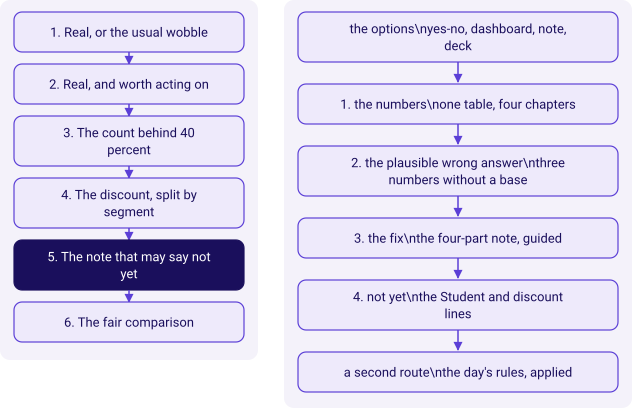

In [2]:
kit.side_by_side(
    kit.ladder(['Real, or the usual wobble', 'Real, and worth acting on', 'The count behind 40 percent', 'The discount, split by segment', 'The note that may say not yet', 'The fair comparison'], lit=4, show=False),
    kit.vflow(['the options\\nyes-no, dashboard, note, deck', '1. the numbers\\none table, four chapters', '2. the plausible wrong answer\\nthree numbers without a base', '3. the fix\\nthe four-part note, guided', '4. not yet\\nthe Student and discount lines', "a second route\\nthe day's rules, applied"], show=False),
)

## The options

Four ways a team could answer Meera in writing. The sizing cell counts what each asks her to read
and what each carries.

| Option | What it is | What it risks |
|---|---|---|
| A. A yes or no per question | Three words she asked for | Every caveat, and the "not yet" she explicitly allowed |
| B. The dashboard | Every number the chapters produced, in one table | Two minutes spent reading, and no decision on the page |
| C. The four-part note | Claim, evidence with its base, caveat, action with its cost, per question | The discipline to keep it under 200 words |
| D. A slide deck | Ten slides for Monday | A meeting to present it; the logic lives in the talk and leaves the page |

Option,Words,Bases carried,What it loses
A. Yes or no,13,none,every caveat
B. Dashboard,506,"all of them, unsorted",the decision
C. Four-part note,200,each claim's,only length
D. Slide deck,ten slides,what the slides draw,a meeting to present


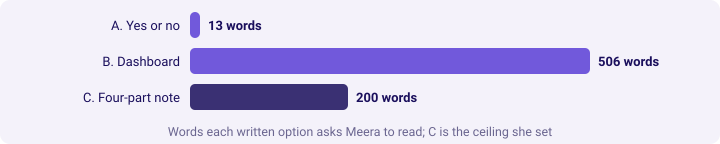

In [3]:
import json

option_a = "Retail-Plus: yes, it is down. Student: yes, move budget. Discount: yes, it worked."
printed = []                                             # the dashboard: everything chapters 1 to 4 printed
for path in sorted(pathlib.Path.cwd().glob("C2_W01_D04_0[1-4]_*_STUDENT.ipynb")):
    for cell in json.loads(path.read_text())["cells"]:
        for out in cell.get("outputs", []):
            printed.append("".join(out.get("text", "")))
option_b = " ".join(printed)
option_c_limit = 200
rows = [("A. Yes or no", len(option_a.split()), "none", "every caveat"),
        ("B. Dashboard", len(option_b.split()), "all of them, unsorted", "the decision"),
        ("C. Four-part note", option_c_limit, "each claim's", "only length"),
        ("D. Slide deck", "ten slides", "what the slides draw", "a meeting to present")]
kit.table(["Option", "Words", "Bases carried", "What it loses"], rows,
          caption="The options sized in words and in what they carry")
kit.bars([(r[0], r[1]) for r in rows[:3]], fmt=lambda v: f"{v} words", lit=[2],
         title="Words each written option asks Meera to read; C is the ceiling she set")
kit.check("the yes-or-no option is short and drops the caveats", len(option_a.split()) < 20 and "not yet" not in option_a)

**The best-fit call: C, the four-part note under 200 words.** It is the only option that carries
each number with its base and a decision in the same place, which is what Meera asked for. A drops
what she explicitly allowed; B and D hand her the analysis instead of the answer. **The fact that
would change the call.** A standing weekly review with the same three metrics: then a small
dashboard with fixed bases beats rewriting the note each week, and the note shrinks to what moved.

## 1. The numbers, in one table

**Predict before you run.** How many of the day's key numbers need a second number beside them
before they can go in a sentence? a) none, they are all final; b) one; c) most of them; d) only the
percentages.

In [4]:
table = [
    ("Retail-Plus fall, share counting falls only", f"{NUMBERS['share']:.3f}", "the world it was counted in"),
    ("Retail-Plus fall, share counting either way", f"{NUMBERS['either']:.3f}", "why both directions are reported"),
    ("Retail-Plus fall, rupees a quarter", kit.rupees(NUMBERS["fall"]), "the company's quarter"),
    ("Company delivered revenue, Q2", kit.rupees(NUMBERS["company"]), "the window"),
    ("Retention offer, rupees a quarter", kit.rupees(NUMBERS["offer"]), "an assumption, said as one"),
    ("Student orders, rise", f"{NUMBERS['student_rise']}%", "the count, and chance on it"),
    ("Student, coin-flip share for that rise", f"{NUMBERS['student_chance']:.3f}", "what it means for the decision"),
    ("Monsoon sale, blended lift", f"{NUMBERS['blend']:+.1%}", "who got it"),
    ("Monsoon sale, inside Retail-Plus", f"{NUMBERS['within']:+.1%}", "the counts per group"),
]
kit.table(["Number", "Value", "What must sit beside it"], table, caption="The day's numbers, each with the base it needs")
kit.check("nine numbers carry forward from chapters 1 to 4", len(table) == 9)
kit.check("every number has a base named beside it", all(t[2] for t in table))

Number,Value,What must sit beside it
"Retail-Plus fall, share counting falls only",0.029,the world it was counted in
"Retail-Plus fall, share counting either way",0.057,why both directions are reported
"Retail-Plus fall, rupees a quarter","Rs 24,420",the company's quarter
"Company delivered revenue, Q2","Rs 1,28,64,680",the window
"Retention offer, rupees a quarter","Rs 11,000","an assumption, said as one"
"Student orders, rise",40%,"the count, and chance on it"
"Student, coin-flip share for that rise",0.397,what it means for the decision
"Monsoon sale, blended lift",+6.1%,who got it
"Monsoon sale, inside Retail-Plus",-3.0%,the counts per group


**What happened.** The answer is c. Every number needs a partner: a share needs its world and its
direction, a rupee figure its whole, a rate its count, a lift its groups. A number without its
partner is the next section's trap.

## 2. The plausible wrong answer

**The plausible wrong answer.** A hurried note uses the three headline percentages, each correct
arithmetic, and each written the way it first appeared.

In [5]:
tier_fall = NUMBERS["fall"] / NUMBERS["tier_q1"]
headline = (f"Retail-Plus revenue fell {tier_fall:.0%}. Student is up {NUMBERS['student_rise']}%. "
            f"The monsoon sale lifted revenue {NUMBERS['blend']:.0%}. We recommend a retention offer for "
            f"Retail-Plus, budget to Student, and the sale again for Diwali.")
print(headline)

Retail-Plus revenue fell 34%. Student is up 40%. The monsoon sale lifted revenue 6%. We recommend a retention offer for Retail-Plus, budget to Student, and the sale again for Diwali.


**Why it is wrong.** Three true numbers lead to three wrong decisions. "Fell 34 percent" is 34
percent of a tier that delivered under one percent of the company's revenue, so Meera hears a crisis
worth Rs 24,420 a quarter. "Up 40 percent" travels without the count chance makes it on. "Lifted 6
percent" is the blend chapter 4 took apart. **The check** is an audit every note line has to pass:
does each number carry its base, its count or chance, and a caveat?

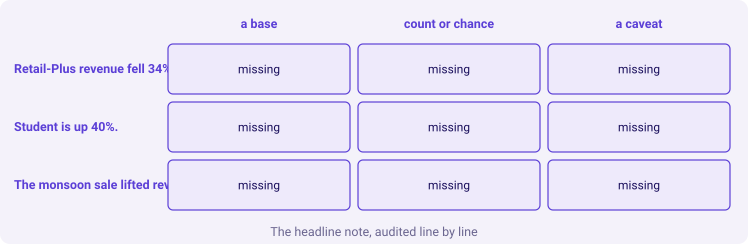

9 of 9 audit cells missing


In [6]:
def audit(line):
    """Three yes-or-no questions per line of a note: base, count or chance, caveat."""
    import re
    low = line.lower()
    base = any(w in low for w in ["of the company", "a quarter", "quarter on quarter", "against rs", "per member",
                                  "than customers"])
    count = any(w in low for w in ["in 100", "chance", "count", "worlds"]) or bool(re.search(r"\b\d+ (customers|orders|members)", low))
    caveat = any(w in low for w in ["if ", "unless", "until", "not yet", "caveat", "because"])
    return ["yes" if x else "missing" for x in (base, count, caveat)]


lines = [s.strip() + "." for s in headline.split(".") if s.strip()][:3]
kit.matrix([l[:34] for l in lines], ["a base", "count or chance", "a caveat"], [audit(l) for l in lines],
           title="The headline note, audited line by line")
missing = sum(a.count("missing") for a in map(audit, lines))
print(f"{missing} of 9 audit cells missing")
kit.check("the headline note fails the audit on most cells", missing >= 7, f"{missing} missing")

## 3. The fix: the four-part note, guided on Retail-Plus

The row asks for the Retail-Plus line to be built together, in four parts, before the other two
are written alone.

**Predict before you run.** Which part does a hurried analyst leave out most often? a) the claim;
b) the evidence; c) the caveat; d) the action.

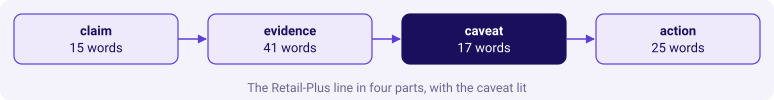

CLAIM: Retail-Plus is spending less by a borderline amount, and it is small against the company.
EVIDENCE: Members delivered Rs 1,110 less each, Rs 24,420 a quarter, 0.19% of the company's quarter; if nothing had changed, a fall that large turns up in about 3 in 100 flips, and a move that large either way in about 6.
CAVEAT: We asked after seeing the fall, and it could be as small as Rs 80 a member.
ACTION: Watch it; if we act, test the Rs 500-a-member offer on a coin-chosen half of the tier, Rs 5,500 a quarter, holding back the rest.


In [7]:
DECISIONS = {"Retail-Plus": "watch, and test before funding", "Student": "not yet",
             "Discount": "do not repeat as designed"}      # the decision each line carries, kept as data
plus_line = {
    "claim": "Retail-Plus is spending less by a borderline amount, and it is small against the company.",
    "evidence": (f"Members delivered Rs 1,110 less each, {kit.rupees(NUMBERS['fall'])} a quarter, "
                 f"{NUMBERS['fall'] / NUMBERS['company']:.2%} of the company's quarter; if nothing had changed, a fall that "
                 f"large turns up in about {round(NUMBERS['share'] * 100)} in 100 flips, and a move that large either way in "
                 f"about {round(NUMBERS['either'] * 100)}."),
    "caveat": f"We asked after seeing the fall, and it could be as small as Rs {round(NUMBERS['low'], -1):,.0f} a member.",
    "action": (f"Watch it; if we act, test the Rs 500-a-member offer on a coin-chosen half of the tier, "
               f"{kit.rupees(NUMBERS['offer'] // 2)} a quarter, holding back the rest."),
}
kit.flow([f"{k}\n{len(v.split())} words" for k, v in plus_line.items()], lit=2,
         title="The Retail-Plus line in four parts, with the caveat lit")
print("\n".join(f"{k.upper()}: {v}" for k, v in plus_line.items()))
kit.check("the Retail-Plus line passes the audit", audit(" ".join(plus_line.values())) == ["yes", "yes", "yes"])

**What happened.** The answer is c: the caveat is the part most often missing, and it is the part a
CEO keeps an analyst for. The Retail-Plus line now carries its base (the company's quarter), its
chance in both directions (about 3 and 6 in 100), its caveat (a question asked after the fall was
seen, and a fall that could be small) and its action with a cost.

## 4. Not yet: the Student and discount lines

"Not yet" is a claim, a caveat and an action in one sentence, provided it names what would turn it
into a yes. Write both lines and audit the whole note.

**Predict before you run.** How many words will the three answers take? a) under 50; b) under 200;
c) about 400; d) over 1,000.

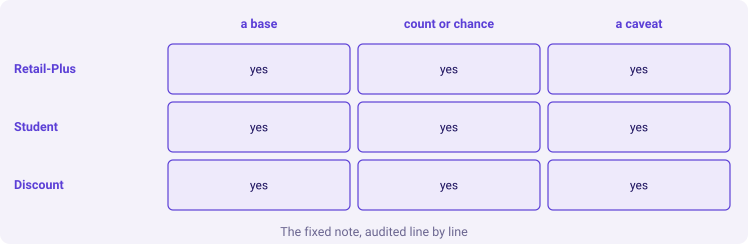

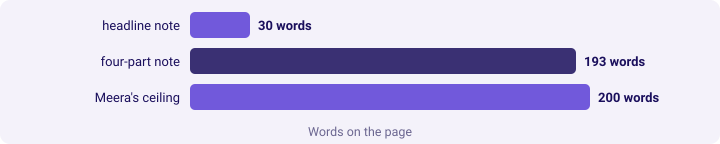

Student orders rose 40 percent quarter on quarter, on a count so small that chance alone makes that rise in about 40 in 100 worlds. Not yet: no budget moves until more customers buy, thirty or more behind the rise.
The monsoon sale did not lift spend: inside each segment, the 30 customers who got it spent about 3% less than customers who did not; the 6% blend is higher only because the exposed group held more Retail-Plus members. Do not repeat it as designed; at Diwali, hold back a random slice of each segment.
the whole note: 193 words
figures in the note: 11; traced to a chapter's number: 11


In [8]:
student_line = (f"Student orders rose {NUMBERS['student_rise']} percent quarter on quarter, on a count so small that chance alone makes "
                f"that rise in about {round(NUMBERS['student_chance'] * 100)} in 100 worlds. Not yet: no budget moves "
                f"until more customers buy, thirty or more behind the rise.")
discount_line = (f"The monsoon sale did not lift spend: inside each segment, the {len(group('yes', 'Retail-Plus'))} customers who got it spent about "
                 f"{abs(NUMBERS['within']):.0%} less than customers who did not; the {NUMBERS['blend']:.0%} blend "
                 f"is higher only because the exposed group held more Retail-Plus members. Do not repeat it as "
                 f"designed; at Diwali, hold back a random slice of each segment.")
note = " ".join(plus_line.values()) + " " + student_line + " " + discount_line
kit.matrix(["Retail-Plus", "Student", "Discount"], ["a base", "count or chance", "a caveat"],
           [audit(" ".join(plus_line.values())), audit(student_line), audit(discount_line)],
           title="The fixed note, audited line by line")
kit.bars([("headline note", len(headline.split())), ("four-part note", len(note.split())), ("Meera's ceiling", 200)],
         fmt=lambda v: f"{v} words", lit=[1], title="Words on the page")
print(student_line)
print(discount_line)
print(f"the whole note: {len(note.split())} words")

import re
found = re.findall(r"Rs [\d,]+|\d+\.\d+%|\d+ percent|\d+ in 100|\d+%", note)
known = {kit.rupees(NUMBERS["fall"]), kit.rupees(NUMBERS["offer"] // 2), "Rs 500", "Rs 1,110",
         f"Rs {round(NUMBERS['low'], -1):,.0f}", f"{NUMBERS['fall'] / NUMBERS['company']:.2%}",
         f"{NUMBERS['student_rise']} percent", f"{round(NUMBERS['share'] * 100)} in 100",
         f"{round(NUMBERS['student_chance'] * 100)} in 100",
         f"{abs(NUMBERS['within']):.0%}", f"{NUMBERS['blend']:.0%}"}
traced = [f for f in found if f in known]
print(f"figures in the note: {len(found)}; traced to a chapter's number: {len(traced)}")
kit.check("the full note is under 200 words", len(note.split()) < 200, f"{len(note.split())}")
kit.check("every line of the fixed note passes the audit",
          all(a == ["yes", "yes", "yes"] for a in [audit(student_line), audit(discount_line)]))
kit.check("every figure in the note traces to a number a chapter computed", found and len(found) == len(traced),
          f"{len(traced)} of {len(found)}")

**What happened.** The answer is b: the three answers fit under Meera's 200 words with their
bases, caveats and actions, against the headline note's 30 words and three wrong decisions, and
every figure in them traces to a number a chapter computed. What changed: three decisions.
Retail-Plus becomes a watch item with a cheap test if anyone acts, Student becomes a watch with a
threshold, and the Diwali sale becomes a redesign with a hold-back.

## A second route: the day's rules, applied to the numbers

The note was written by hand from the chapters. Reach its three decisions a second way: apply the
rule each chapter ended on to that chapter's numbers, mechanically, and compare the decisions with
the ones the note carries. A note whose action does not follow from its own numbers would pass every
figure check and fail here.

**Predict before you run.** How many of the note's three decisions will the rules reach on their
own? a) none, since rules cannot write; b) one; c) two; d) all three.

Question,The rule,Does it hold?,Decision the rule gives,Decision the note carries
Retail-Plus,chapter 2: the range's low end sits below the offer's cost per member,yes,"watch, and test before funding","watch, and test before funding"
Student,chapter 3: fewer than thirty customers stand behind the rise,yes,not yet,not yet
Discount,chapter 4: the blend rose while every segment fell,yes,do not repeat as designed,do not repeat as designed


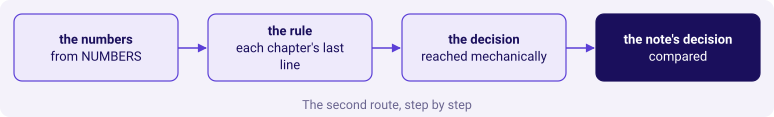

In [9]:
rules = [
    ("Retail-Plus", "chapter 2: the range's low end sits below the offer's cost per member",
     NUMBERS["low"] < 500, "watch, and test before funding", "fund the offer"),
    ("Student", "chapter 3: fewer than thirty customers stand behind the rise",
     student_buyers < 30, "not yet", "move the budget"),
    ("Discount", "chapter 4: the blend rose while every segment fell",
     NUMBERS["blend"] > 0 and max(NUMBERS["within"], NUMBERS["within_core"]) < 0, "do not repeat as designed", "repeat it"),
]
reached = {q: (yes if test else no) for q, _, test, yes, no in rules}
kit.table(["Question", "The rule", "Does it hold?", "Decision the rule gives", "Decision the note carries"],
          [(q, rule, "yes" if test else "no", reached[q], DECISIONS[q]) for q, rule, test, _, _ in rules],
          caption="The note's decisions, reached a second way from the numbers alone")
kit.flow(["the numbers\nfrom NUMBERS", "the rule\neach chapter's last line", "the decision\nreached mechanically",
          "the note's decision\ncompared"], lit=3, title="The second route, step by step")
kit.check("the rules reach all three of the note's decisions", reached == DECISIONS, f"{sum(reached[q] == DECISIONS[q] for q in DECISIONS)} of 3")

**What happened.** The answer is d. Applied to the numbers alone, the rules reach the note's three
decisions, so the note's actions follow from its evidence and from nothing else. **When to switch.**
Apply the rules by hand for a one-off note; write them as code, as this cell does, when the same
note is produced every week, because a rule in code cannot drift toward the answer someone wants.

> **Kavya's review.** "Three answers, each with its base, its caveat and a cost, and two of them say
> not yet with the thing that would change them. Marketing will push on the third on Monday; the
> next chapter is the ground you will stand on."

### In the interview

**[S] Explain a finding to a non-technical stakeholder.** "Claim first, in one sentence, with one
number and its base. Then the evidence, the caveat that would change the claim, and the action with
what it costs. If the honest answer is not yet, I say so and name what would turn it into a yes, and
by when."

**[D] The CEO wants a yes or no and the honest answer is 'not yet'; what do you say, and how do you
hold the line when marketing pushes?** "Not yet, and here is what would tell us by when. I offer the
cheapest test that settles it, such as a held-back group at Diwali. I hold the line with the split
and leave authority out of it: I show their number reproduced, then the segments, and invite them to
find the flaw."

**[D] One-line answers, a dashboard or a written note: which do you send a CEO before a review, and
when would you switch?** "A written note under a page, each claim with its base and its caveat. I
switch to a small dashboard when the same metrics are reviewed every week, so the note only covers
what moved."

### Depth: the fact that would flip each line

A note is stronger when it says, per line, what would change it. The table is the caveat column
made explicit.

Question,Today's line,The fact that would flip it
Retail-Plus,"borderline, small, watch it","a second quarter with a larger fall, or a recovery rate from a past offer"
Student,not yet,"thirty or more customers behind the rise, with the rise holding"
Discount,do not repeat as designed,a random hold-back at Diwali showing a lift inside segments


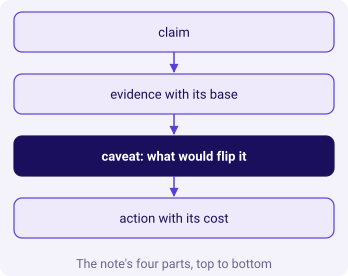

In [10]:
flips_table = [("Retail-Plus", "borderline, small, watch it", "a second quarter with a larger fall, or a recovery rate from a past offer"),
               ("Student", "not yet", "thirty or more customers behind the rise, with the rise holding"),
               ("Discount", "do not repeat as designed", "a random hold-back at Diwali showing a lift inside segments")]
kit.table(["Question", "Today's line", "The fact that would flip it"], flips_table)
kit.vflow(["claim", "evidence with its base", "caveat: what would flip it", "action with its cost"], lit=2,
          title="The note's four parts, top to bottom")
kit.check("every line names the fact that would flip it", all(r[2] for r in flips_table))

In [11]:
kit.check_summary()
print("Next: chapter 6, this afternoon. Who got the discount, who did not, and what else changed?")

Next: chapter 6, this afternoon. Who got the discount, who did not, and what else changed?
